<a href="https://colab.research.google.com/github/sumyuck/ML-learning/blob/main/ml/ML_p_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (150, 6)

Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Class Distribution:
 Species
0    50
1    50
2    50
Name: count, dtype: int64

CART Accuracy: 0.9333333333333333


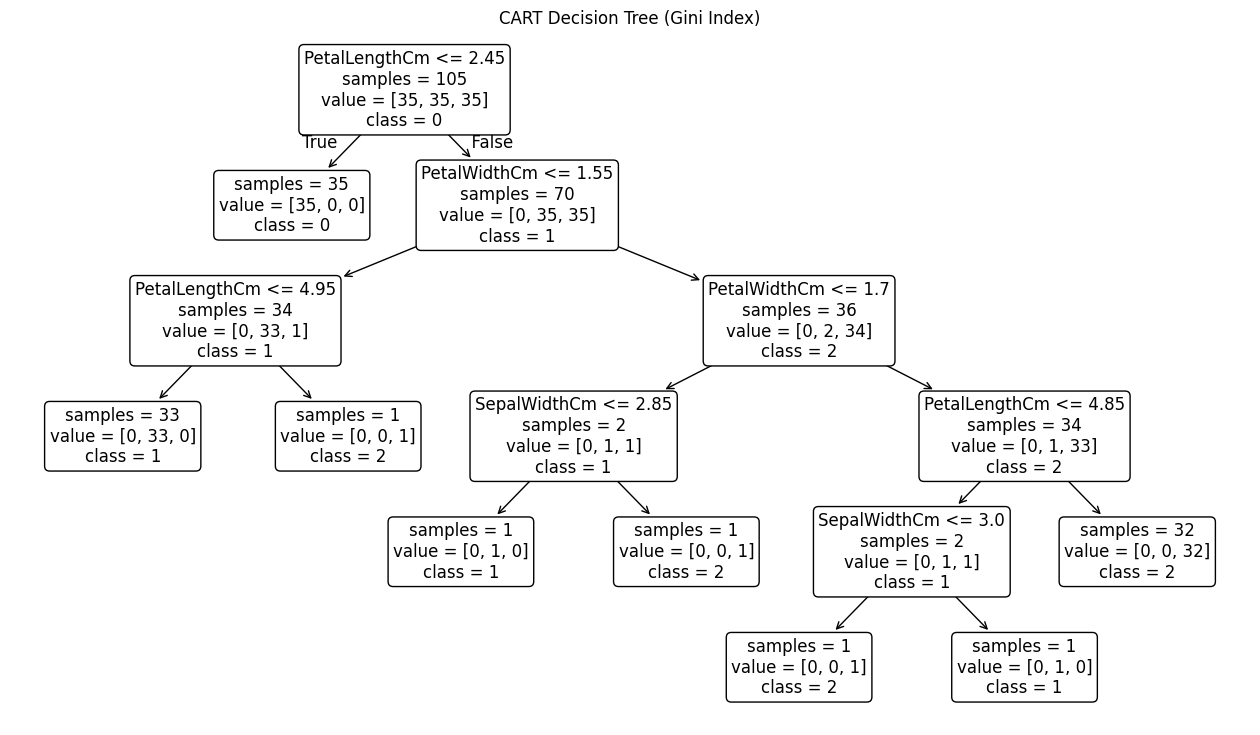


ID3 Accuracy: 0.8888888888888888


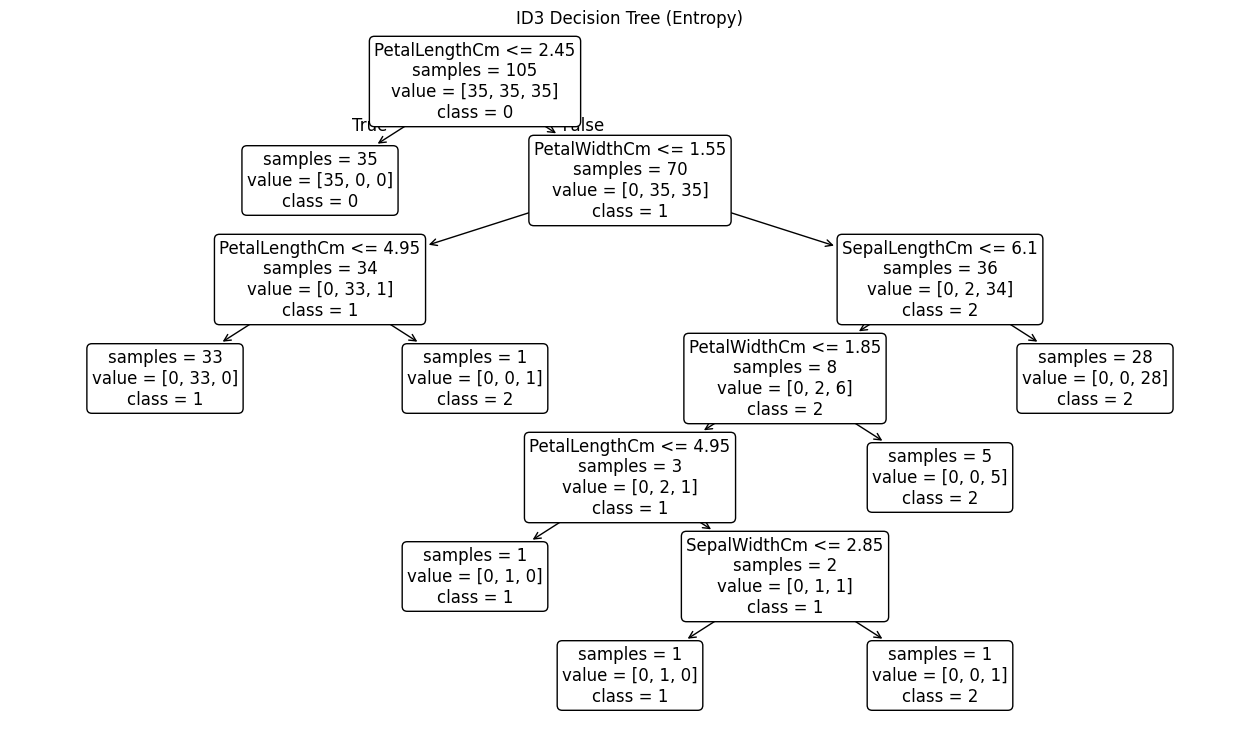


C4.5 Accuracy: 0.8444444444444444


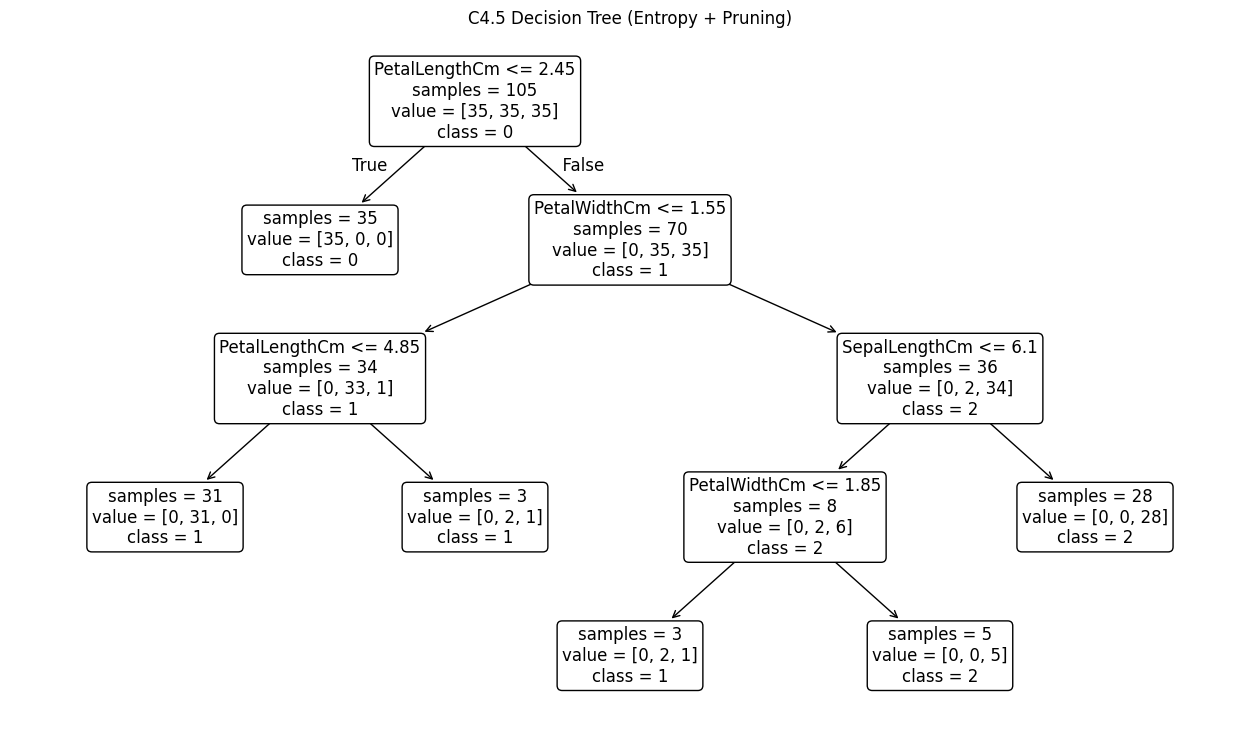

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

df = pd.read_csv("/content/Iris.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass Distribution:\n", df["Species"].value_counts())

X = df.drop(columns=["Species", "Id"]).values
y = df["Species"].values

feature_names = df.drop(columns=["Species", "Id"]).columns
class_names = df["Species"].unique().astype(str).tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# CART (Gini Index)
cart = DecisionTreeClassifier(criterion="gini", random_state=42)
cart.fit(X_train, y_train)
y_pred = cart.predict(X_test)
print("\nCART Accuracy:", accuracy_score(y_test, y_pred))

plt.figure(figsize=(16, 9))
plot_tree(
    cart,
    feature_names=feature_names,
    class_names=class_names,
    filled=False,
    impurity=False,
    rounded=True,
    fontsize=12
)
plt.title("CART Decision Tree (Gini Index)")
plt.show()

# ID3 (Entropy)
id3 = DecisionTreeClassifier(criterion="entropy", random_state=42)
id3.fit(X_train, y_train)
y_pred = id3.predict(X_test)
print("\nID3 Accuracy:", accuracy_score(y_test, y_pred))

plt.figure(figsize=(16, 9))
plot_tree(
    id3,
    feature_names=feature_names,
    class_names=class_names,
    filled=False,
    impurity=False,
    rounded=True,
    fontsize=12
)
plt.title("ID3 Decision Tree (Entropy)")
plt.show()

# C4.5 (Entropy + Pruning)
c45 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)
c45.fit(X_train, y_train)
y_pred = c45.predict(X_test)
print("\nC4.5 Accuracy:", accuracy_score(y_test, y_pred))

plt.figure(figsize=(16, 9))
plot_tree(
    c45,
    feature_names=feature_names,
    class_names=class_names,
    filled=False,
    impurity=False,
    rounded=True,
    fontsize=12
)
plt.title("C4.5 Decision Tree (Entropy + Pruning)")
plt.show()


CART Accuracy: 0.9333333333333333


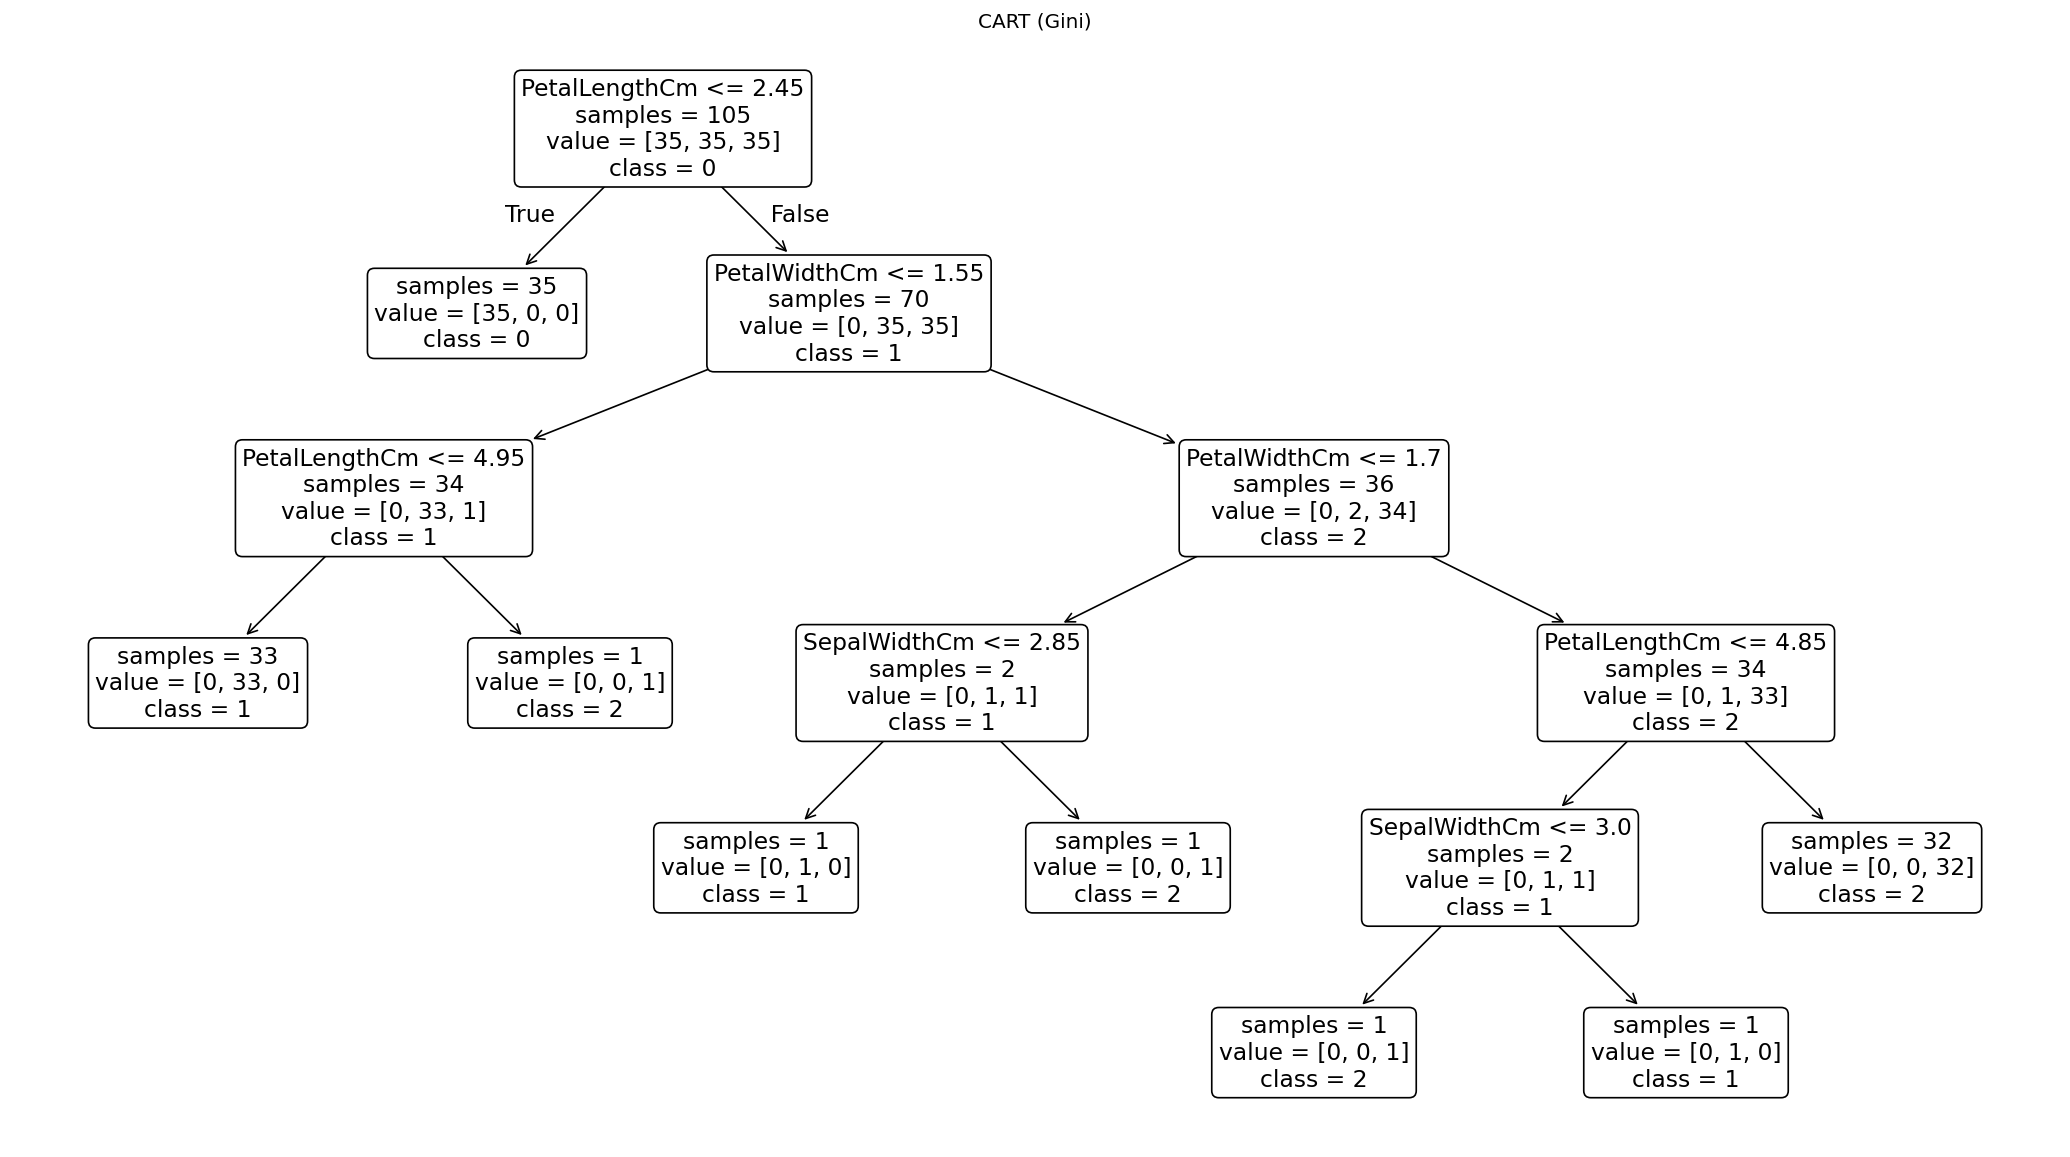

ID3 Accuracy: 0.9111111111111111


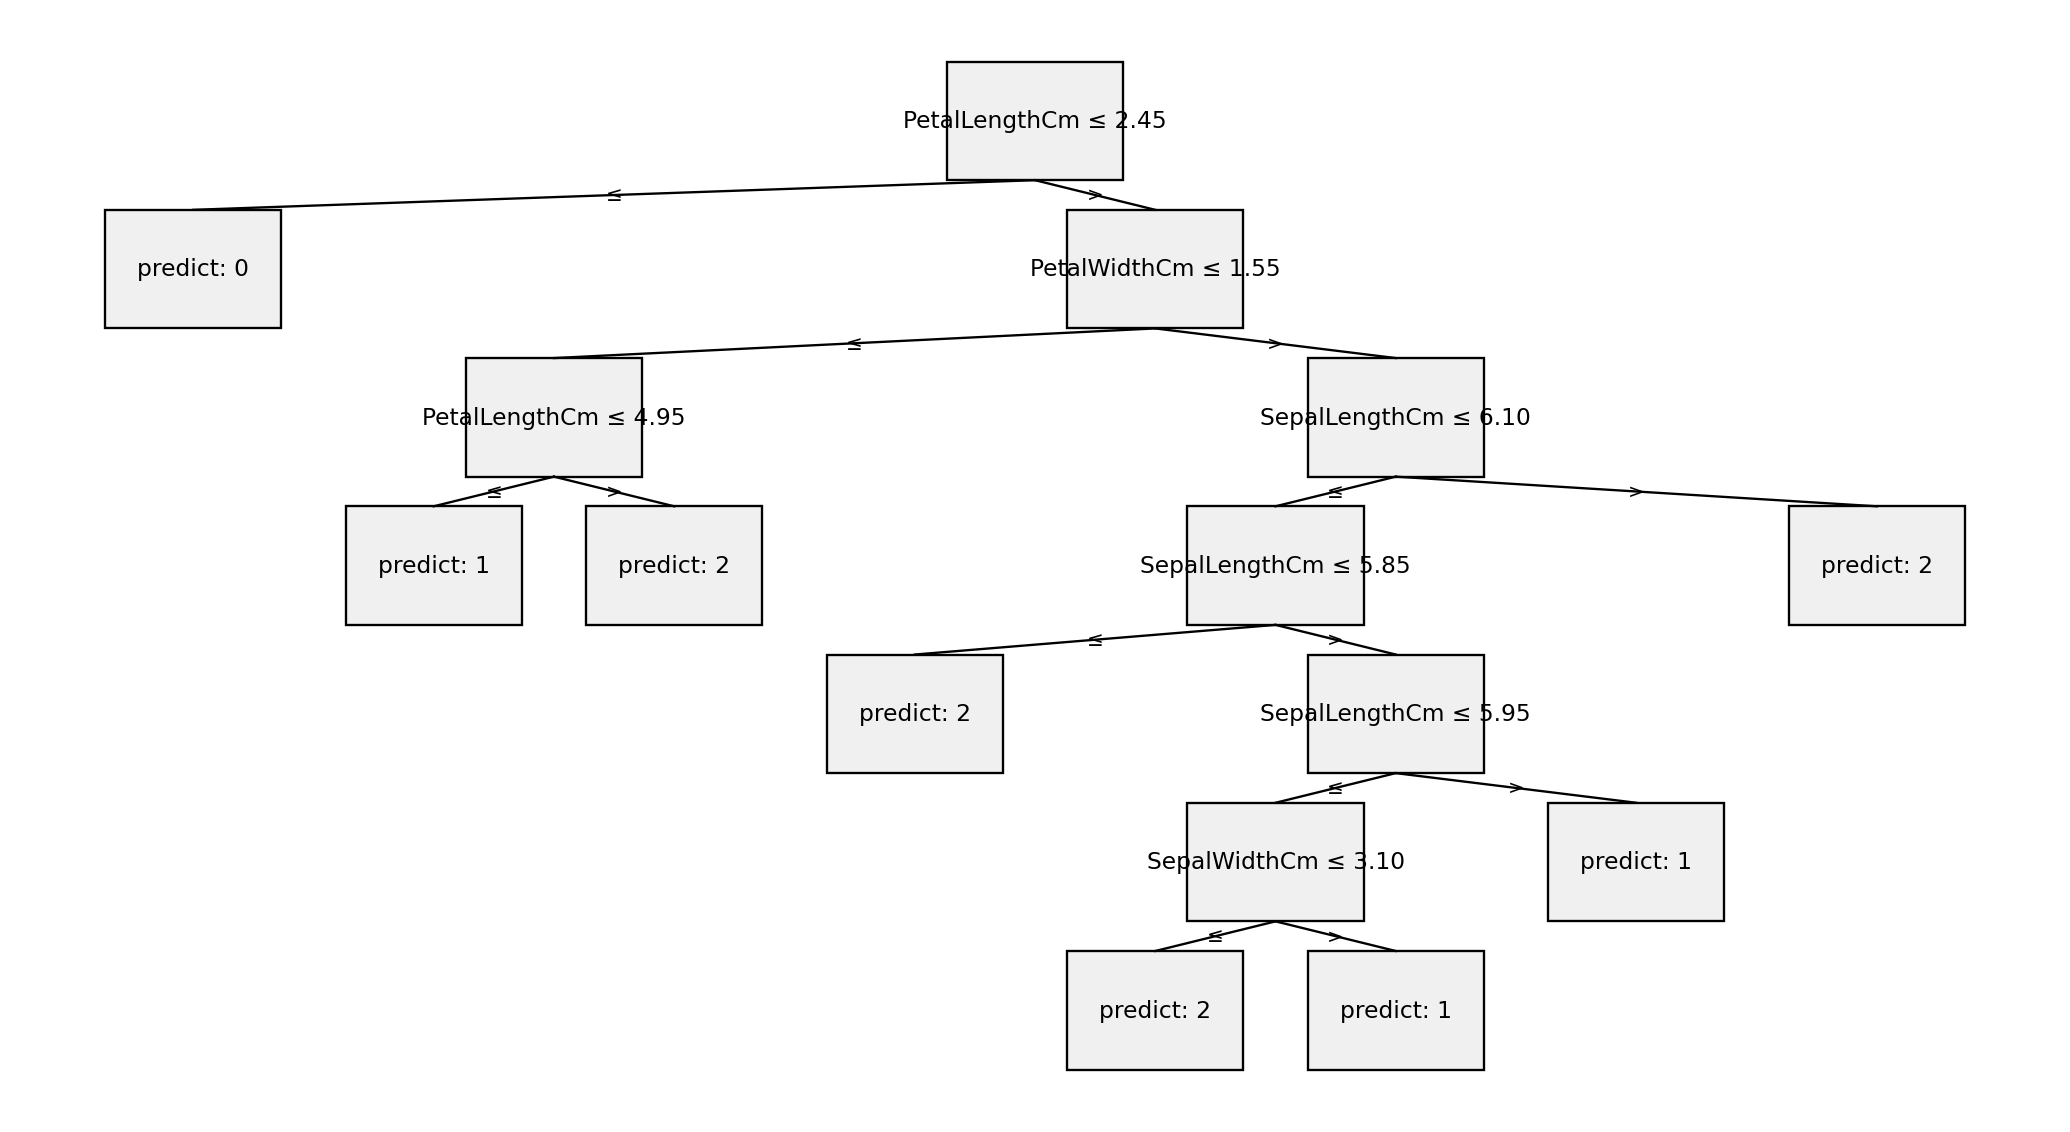

C4.5 Accuracy: 0.9333333333333333


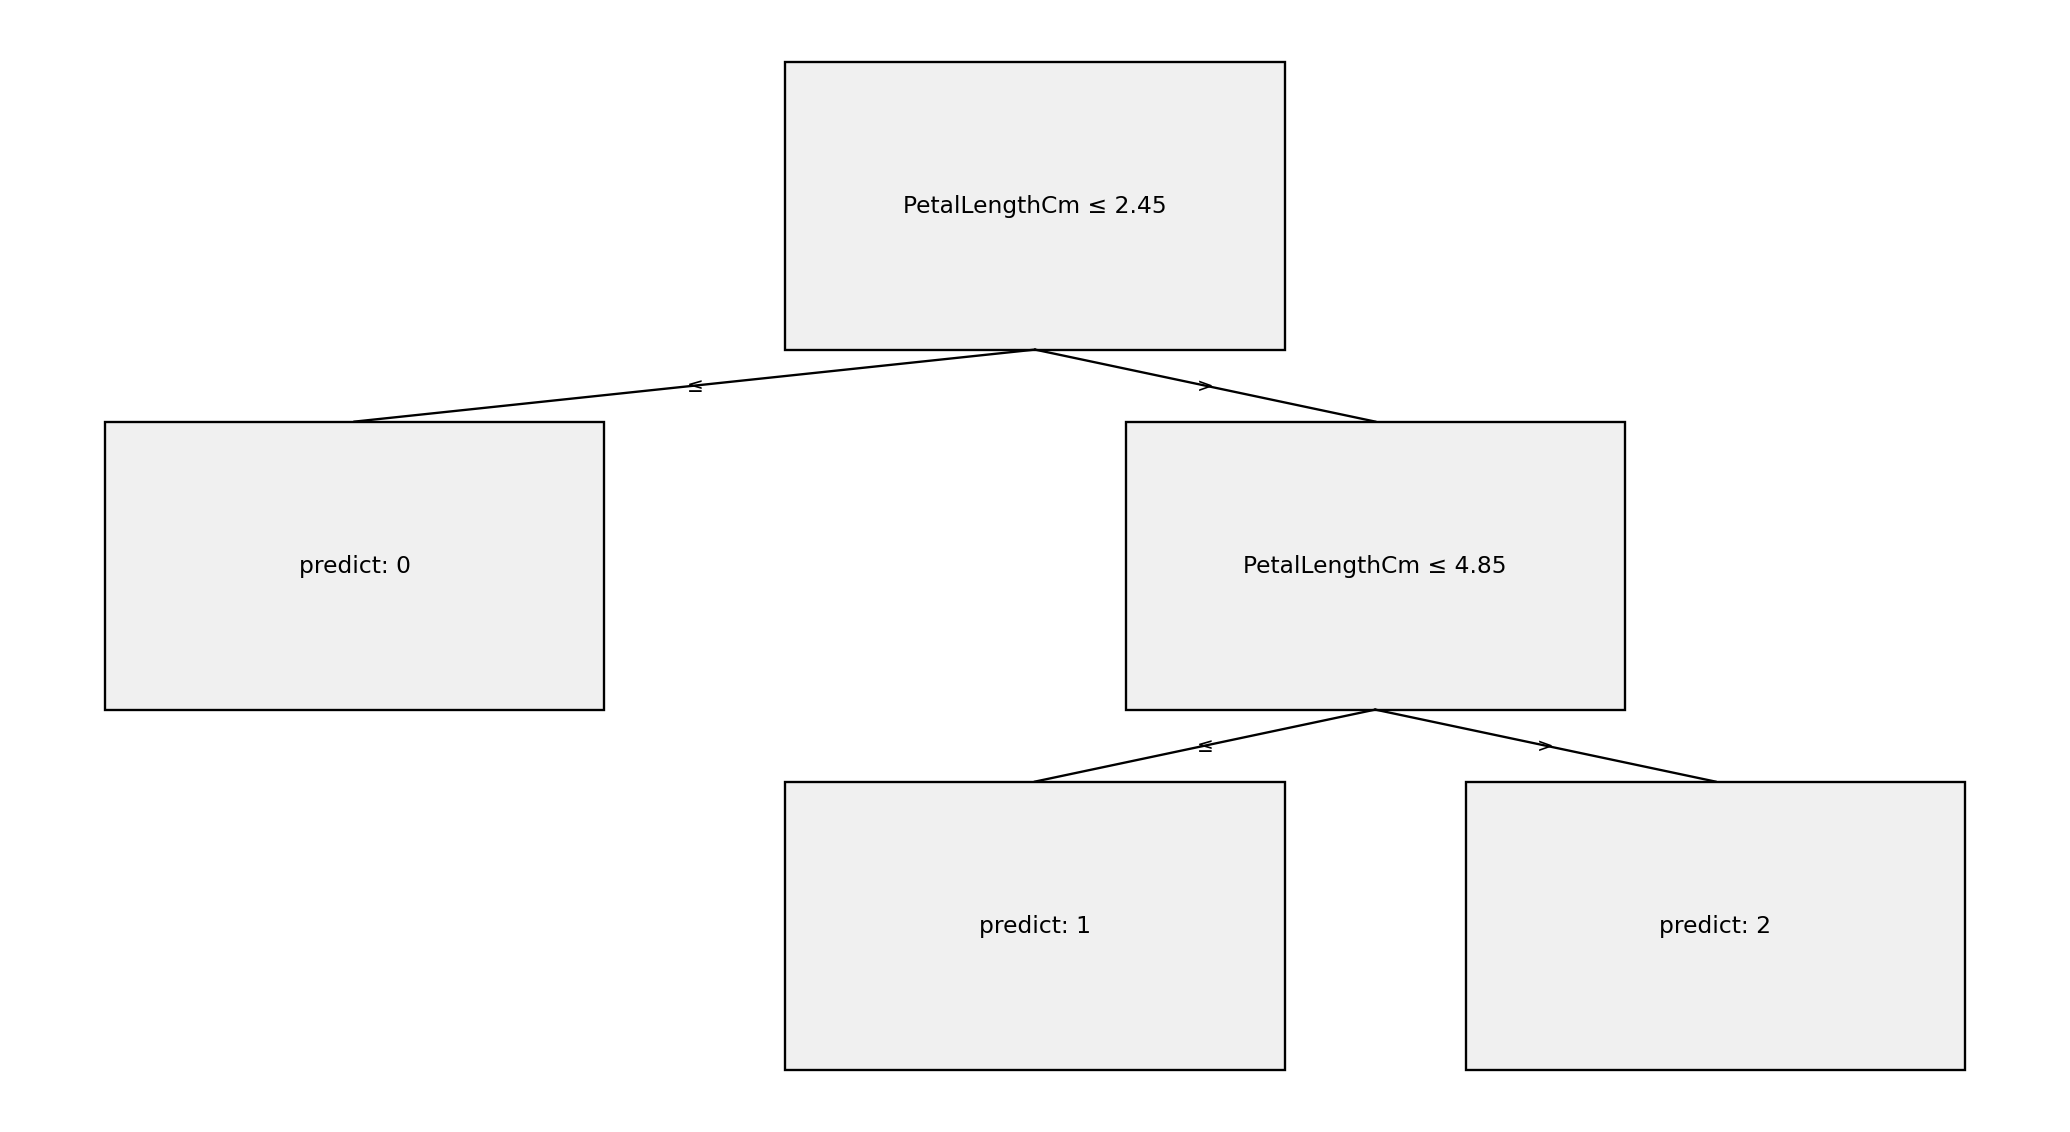

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from dataclasses import dataclass
from typing import Optional, Any, List, Tuple
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

IRIS_PATH = "/content/Iris.csv"

df = pd.read_csv(IRIS_PATH)
X = df.drop(columns=["Species", "Id"]).values.astype(float)
y = df["Species"].values
feature_names = df.drop(columns=["Species", "Id"]).columns.tolist()
class_names = sorted(df["Species"].unique().astype(str).tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

def entropy(labels: np.ndarray) -> float:
    n = len(labels)
    if n == 0:
        return 0.0
    counts = Counter(labels)
    return -sum((c/n) * math.log2(c/n) for c in counts.values())

def info_gain(y, y_left, y_right, impurity):
    n = len(y)
    if n == 0:
        return 0.0
    wl = len(y_left)/n
    wr = len(y_right)/n
    return impurity(y) - (wl * impurity(y_left) + wr * impurity(y_right))

def split_info(y_left, y_right) -> float:
    n = len(y_left) + len(y_right)
    if n == 0:
        return 0.0
    val = 0.0
    for c in (len(y_left), len(y_right)):
        if c == 0:
            continue
        p = c / n
        val += -p * math.log2(p)
    return val

def candidate_thresholds(col: np.ndarray) -> List[float]:
    uniq = np.unique(col)
    if len(uniq) <= 1:
        return []
    return [(uniq[i] + uniq[i+1]) / 2.0 for i in range(len(uniq)-1)]

def majority_label(labels: np.ndarray) -> Any:
    return Counter(labels).most_common(1)[0][0]

def partition(X: np.ndarray, y: np.ndarray, j: int, thr: float):
    mask = X[:, j] <= thr
    return X[mask], y[mask], X[~mask], y[~mask]

def all_same(labels: np.ndarray) -> bool:
    return len(set(labels)) == 1

def features_constant(X: np.ndarray) -> bool:
    return np.allclose(X, X[:1])

@dataclass
class Node:
    is_leaf: bool
    prediction: Optional[Any] = None
    feature_index: Optional[int] = None
    threshold: Optional[float] = None
    left: Optional["Node"] = None
    right: Optional["Node"] = None
    depth: int = 0

class DecisionTreeScratch:
    def __init__(self, criterion: str = "entropy", max_depth: Optional[int] = None,
                 min_samples_split: int = 2, min_samples_leaf: int = 1, random_state: int = 42):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.rng = np.random.default_rng(random_state)
        self.root: Optional[Node] = None
        self.n_features_: int = 0
        self.classes_: List[Any] = []

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.n_features_ = X.shape[1]
        self.classes_ = sorted(list(set(y)))
        self.root = self._build(X, y, depth=0)
        return self

    def _best_split(self, X: np.ndarray, y: np.ndarray) -> Tuple[Optional[int], Optional[float], float]:
        best_feat, best_thr, best_score = None, None, -np.inf
        for j in range(self.n_features_):
            thrs = candidate_thresholds(X[:, j])
            if not thrs:
                continue
            for thr in thrs:
                Xl, yl, Xr, yr = partition(X, y, j, thr)
                if len(yl) < self.min_samples_leaf or len(yr) < self.min_samples_leaf:
                    continue
                if self.criterion == "entropy":
                    score = info_gain(y, yl, yr, entropy)
                elif self.criterion == "gain_ratio":
                    gain = info_gain(y, yl, yr, entropy)
                    si = split_info(yl, yr)
                    score = (gain / si) if si > 0 else 0.0
                else:
                    raise ValueError("Unknown criterion")
                if score > best_score:
                    best_score, best_feat, best_thr = score, j, thr
        return best_feat, best_thr, best_score

    def _build(self, X: np.ndarray, y: np.ndarray, depth: int) -> Node:
        if len(y) == 0:
            return Node(is_leaf=True, prediction=None, depth=depth)
        if all_same(y):
            return Node(is_leaf=True, prediction=y[0], depth=depth)
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(is_leaf=True, prediction=majority_label(y), depth=depth)
        if len(y) < self.min_samples_split or features_constant(X):
            return Node(is_leaf=True, prediction=majority_label(y), depth=depth)
        j, thr, _ = self._best_split(X, y)
        if j is None:
            return Node(is_leaf=True, prediction=majority_label(y), depth=depth)
        Xl, yl, Xr, yr = partition(X, y, j, thr)
        if len(yl) == 0 or len(yr) == 0:
            return Node(is_leaf=True, prediction=majority_label(y), depth=depth)
        left = self._build(Xl, yl, depth + 1)
        right = self._build(Xr, yr, depth + 1)
        return Node(is_leaf=False, feature_index=j, threshold=thr, left=left, right=right, depth=depth)

    def predict_one(self, x: np.ndarray) -> Any:
        node = self.root
        while node and not node.is_leaf:
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.prediction if node else None

    def predict(self, X: np.ndarray) -> List[Any]:
        return [self.predict_one(row) for row in X]

    def accuracy(self, X: np.ndarray, y: np.ndarray) -> float:
        return accuracy_score(y, self.predict(X))

def reduced_error_prune(tree: DecisionTreeScratch, X_val: np.ndarray, y_val: np.ndarray):
    def prune(node: Node, X_sub: np.ndarray, y_sub: np.ndarray):
        if node.is_leaf or len(X_sub) == 0:
            return
        mask = X_sub[:, node.feature_index] <= node.threshold
        Xl, yl = X_sub[mask], y_sub[mask]
        Xr, yr = X_sub[~mask], y_sub[~mask]
        prune(node.left, Xl, yl)
        prune(node.right, Xr, yr)
        if len(y_sub) == 0:
            return
        acc_before = tree.accuracy(X_val, y_val)
        backup = (node.is_leaf, node.prediction, node.feature_index, node.threshold, node.left, node.right)
        node.is_leaf = True
        node.prediction = majority_label(y_sub)
        node.feature_index = None
        node.threshold = None
        node.left = None
        node.right = None
        acc_after = tree.accuracy(X_val, y_val)
        if acc_after + 1e-12 < acc_before:
            (node.is_leaf, node.prediction, node.feature_index, node.threshold, node.left, node.right) = backup
    if tree.root is not None:
        prune(tree.root, X_val, y_val)

def compute_layout(node: Node, x_spacing=2.5):
    xs = {}
    ys = {}
    def width(n: Node) -> int:
        if n.is_leaf:
            return 1
        return width(n.left) + width(n.right)
    def assign_x(n: Node, xstart: float, xend: float, y: int):
        xs[id(n)] = (xstart + xend) / 2.0
        ys[id(n)] = -y
        if not n.is_leaf:
            wl = width(n.left)
            wr = width(n.right)
            total = wl + wr
            mid = xstart + (wl/total) * (xend - xstart)
            assign_x(n.left, xstart, mid, y + 1)
            assign_x(n.right, mid, xend, y + 1)
    w = width(node) * x_spacing
    assign_x(node, 0.0, float(w), 0)
    return xs, ys

def draw_tree(node: Node, feature_names: List[str], class_names: List[str],
              node_w=2.2, node_h=0.8, linewidth=1.4, fontsize=14):
    fig, ax = plt.subplots(figsize=(22, 12), dpi=120)
    xs, ys = compute_layout(node, x_spacing=3.0)
    def draw_node(n: Node):
        x, y = xs[id(n)], ys[id(n)]
        if n.is_leaf:
            text = f"predict: {n.prediction}"
        else:
            fname = feature_names[n.feature_index]
            text = f"{fname} ≤ {n.threshold:.2f}"
        rect = plt.Rectangle((x - node_w/2, y - node_h/2), node_w, node_h,
                             fill=True, edgecolor="black", facecolor="#f0f0f0", linewidth=linewidth)
        ax.add_patch(rect)
        ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)
        if not n.is_leaf:
            for child, label in [(n.left, "≤"), (n.right, ">")]:
                cx, cy = xs[id(child)], ys[id(child)]
                ax.plot([x, cx], [y - node_h/2, cy + node_h/2],
                        color="black", linewidth=linewidth)
                lx = (x + cx) / 2
                ly = (y + cy) / 2
                ax.text(lx, ly, label, fontsize=fontsize-2, ha="center", va="center")
            draw_node(n.left)
            draw_node(n.right)
    draw_node(node)
    ax.set_axis_off()
    plt.show()

cart = DecisionTreeClassifier(criterion="gini", random_state=42)
cart.fit(X_train, y_train)
cart_pred = cart.predict(X_test)
print("CART Accuracy:", accuracy_score(y_test, cart_pred))
plt.figure(figsize=(22, 12), dpi=120)
plot_tree(cart, feature_names=feature_names, class_names=class_names,
          filled=False, impurity=False, rounded=True, fontsize=14)
plt.title("CART (Gini)")
plt.show()

id3_tree = DecisionTreeScratch(criterion="entropy", random_state=42).fit(X_train, y_train)
id3_pred = id3_tree.predict(X_test)
print("ID3 Accuracy:", accuracy_score(y_test, id3_pred))
draw_tree(id3_tree.root, feature_names, class_names)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=7, stratify=y_train)
c45_tree = DecisionTreeScratch(criterion="gain_ratio", random_state=42).fit(X_tr, y_tr)
reduced_error_prune(c45_tree, X_val, y_val)
c45_pred = c45_tree.predict(X_test)
print("C4.5 Accuracy:", accuracy_score(y_test, c45_pred))
draw_tree(c45_tree.root, feature_names, class_names)
